In [1]:
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from scipy import stats

In [ ]:
zip_path = "cranberry-data.zip"
extract_to = "cranberry_data" 

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print("Unzipped successfully!")

Unzipped successfully!


In [2]:
path = r"cranberry_data\cranberry-data\data_mixed\Phenolics_RawData.xlsx"
df = pd.read_excel(path, engine="openpyxl")
df.head()

,Date,Sample ID,Tube#,Rep1 Absorbance 765 nm,Rep2 Absorbance 765 nm,Rep3 Absorbance 765 nm
0,2025-01-06,Std0,0,0.023,0.020,0.006
1,2025-01-06,Std50,50,0.066,0.064,0.061
2,2025-01-06,std100,100,0.109,0.119,0.116
3,2025-01-06,std150,150,0.177,0.194,0.176
4,2025-01-06,std250,250,0.271,0.292,0.308


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128 entries, 0 to 127
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Date                    128 non-null    datetime64[ns]
 1   Sample ID               128 non-null    object        
 2   Tube#                   128 non-null    int64         
 3   Rep1 Absorbance 765 nm  128 non-null    float64       
 4   Rep2 Absorbance 765 nm  128 non-null    float64       
 5   Rep3 Absorbance 765 nm  128 non-null    float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(1)
memory usage: 6.1+ KB


In [5]:
df

,Date,Sample ID,Tube#,Rep1 Absorbance 765 nm,Rep2 Absorbance 765 nm,Rep3 Absorbance 765 nm
0,2025-01-06,Std0,0,0.023,0.020,0.006
1,2025-01-06,Std50,50,0.066,0.064,0.061
2,2025-01-06,std100,100,0.109,0.119,0.116
3,2025-01-06,std150,150,0.177,0.194,0.176
4,2025-01-06,std250,250,0.271,0.292,0.308
...,...,...,...,...,...,...
123,2025-01-16,std750,750,0.793,0.780,0.802
124,2025-01-16,MQB3,76,0.177,0.155,0.156
125,2025-01-16,MQAC2,77,0.500,0.194,0.195
126,2025-01-16,STA02,78,0.183,0.186,0.188


In [11]:
df.columns

Index(['Date', 'Sample ID', 'Tube#', 'Rep1 Absorbance 765 nm',
       'Rep2 Absorbance 765 nm', 'Rep3 Absorbance 765 nm'],
      dtype='object')

In [4]:
df_long = df.melt(
    id_vars=["Date","Sample ID","Tube#"],
    value_vars=[
        "Rep1 Absorbance 765 nm",
        "Rep2 Absorbance 765 nm",
        "Rep3 Absorbance 765 nm"
    ],
    var_name="rep",
    value_name="absorbance"
)


In [5]:
df_long["rep"] = df_long["rep"].str.extract(r"(Rep\d)")

df_long["is_std"] = df_long["Sample ID"].str.lower().str.startswith("std")

In [6]:
models = {}

for (date, rep), g in df_long[df_long["is_std"]].groupby(["Date","rep"]):

    x = g["Tube#"]
    y = g["absorbance"]

    m, b = np.polyfit(x, y, 1)

    models[(date, rep)] = (m, b)

In [7]:
def estimate_conc(row):

    if row["is_std"]:
        return None

    m, b = models[(row["Date"], row["rep"])]

    x = (row["absorbance"] - b) / m

    return 10 * x

df_long["estimated_conc"] = df_long.apply(estimate_conc, axis=1)

In [26]:
date = "2025-01-07"
rep = "Rep1"

subset = df_long[
    (df_long["Date"] == date) &
    (df_long["rep"] == rep) &
    (df_long["is_std"])
]

In [27]:
x = subset["Tube#"]
y = subset["absorbance"]

In [28]:
m, b = np.polyfit(x, y, 1)

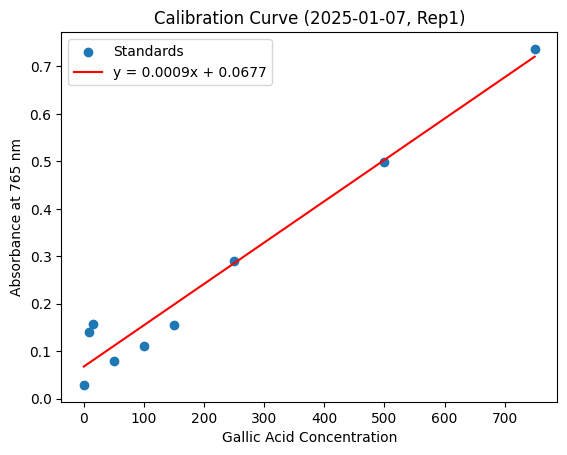

In [29]:
plt.scatter(x, y, label="Standards")

x_line = np.linspace(x.min(), x.max(), 100)
y_line = m * x_line + b

plt.plot(x_line, y_line, color="red", label=f"y = {m:.4f}x + {b:.4f}")

plt.xlabel("Gallic Acid Concentration")
plt.ylabel("Absorbance at 765 nm")
plt.title(f"Calibration Curve ({date}, {rep})")

plt.legend()
plt.show()